<a href="https://colab.research.google.com/github/andaba2101/telecom-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print("Cantidad de valores nulos") # Cantidad de valores nulos
print(users.isna().sum())
print()
print("Proporción de valores nulos")
print(users.isna().mean()) # Proporción de valores nulos
print()

print('Experimentación')
premium = users[users['plan'] == 'Premium']
print(users["city"].isna().groupby(users["plan"]).mean()) #queria rvisar si los nulos en las ciudades tienen relación con el plan escogido (MCAR)
print()
print(users['city'].isna().groupby(users['age']).mean()) #queria saber si hay relacion con algun grupo de edad en partiuclar (MCAR)
print()
print(premium['plan'].groupby(premium["city"]).count()/premium['plan'].groupby(premium["city"]).count().sum() * 100) #queria saber el pocentaje de personas con el plan premium por ciudad
print()
print(users['plan'].groupby(users["city"]).value_counts(normalize=True)) #queria ver la relación de los planes comprados por ciudad (se detecta sentinel ?)
print()
print(users['age'].groupby(users['city'].isna()).mean()) # queria agrupar por valores nulos y no nulos y que media de la edad estaba en cada uno (MAR)
print()
print(users["churn_date"].isna().groupby(users["plan"]).mean()) #queria revisar el porcentaje de fechas de baja tenian relación con el plan escogido, pero son similares (MCAR)
print()
print(users['city'].unique()) #queira confirmar los sentinels

Cantidad de valores nulos
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64

Experimentación
plan
Basico     0.115992
Premium    0.119573
Name: city, dtype: float64

age
-999    0.036364
 18     0.123077
 19     0.107692
 20     0.140625
 21     0.140351
          ...   
 75     0.129032
 76     0.163934
 77     0.086207
 78     0.113924
 79     0.084746
Name: city, Length: 63, dtype: float64

city
?            2.506063
Bogotá      23.120453
CDMX        20.695230
Cali        13.096200
GDL         12.287793
MTY         10.670978
Medellín    17.623282
Name: plan, dtype: float64

city      plan   
?         Basico     0.677083
          Premium    0.322917
Bog

In [ ]:
# cantidad de nulos para usage
print("Cantidad de valores nulos") # Cantidad de valores nulos
print(usage.isna().sum())
print()
print("Proporción de valores nulos")
print(usage.isna().mean()) # Proporción de valores nulos
print()
print(usage['type'].unique())
print()
print('Relación de nulos en date con el type')
print(usage['date'].isna().groupby(usage['type']).mean())

Cantidad de valores nulos
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64

['call' 'text']

Relación de nulos en date con el type
type
call    0.001452
text    0.001086
Name: date, dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?


RTA: En la columna de churn_date del dataframe de users de puede observar un nivel de missingness del 88% lo cual hace practicamente imposible su imputación sin que afecten los datos propios o las posible relaciones con las demás columnas por lo que la mejor opción resultaría en eliminarla. Sin embargo, según la IA esta columna refiere a la fecha en la que los clientes se dieron de baja por lo que constituye un MNAR ya que al no haber fecha es señal de que siguen activos con la compañia por lo que se mantiene

Por su parte, la columna city en el mismo dataframe sugiere una eliminación cautelosa, dado que la variable no parece depender de ninguna otra columna, ya que hay muchas ciudades en cada país y no parece haber una relación clara de inferencia para poder imputar esos datos faltantes. A su vez también se detectó un sentinels con el simbolo ?

Por su parte el df de usage muestra valores faltantes en las columnas de duración, longitud y fecha. Visto lo visto longitud representa cuantos caracteres se enviaron en un SMS mientras que length representa el tiempo en llamada por lo que el primero solo está relacionado con mensajes y el segundo con Calls lo que explica el patrón de nulos de de duration y length siendo esto MNAR. Con respecto a fecha si constituye un MCAR ya que no hay relación con ninguna otra variable (esto se confirma al ver la relación de nulos de las fchas con su participación en el tipo de uso que se da durante todo el data frame) y su porcetaje de missingness es bajo

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
""""
def explorar_num(df, columnas):
    print(df.info())
    for col in columnas:
        print(),
        print(f"{col}: Estadisticas descriptivas"),
        print(df[col].describe()),
        print()
    return df
print(users['user_id'].dtype)

col_num_users = users[['user_id', 'age']]
explorar_num(users, col_num_users)

print('________________________________________________')
HASTA AQUÍ EXPERIMENTÉ CON CREAR FUNCIONES (ELIMINÉ EL CODIGO DE CALCULOS MAUALES POR ESPACIO, PERO SE ENTIENDE LA EXPERIMENTACION INICIAL"""

def explorar(df, columnas):
    print(df.info())
    for col in columnas:
        if df[col].dtype == 'int64' or df[col].dtype == 'float64':
            print(),
            print(f"Estadisticas descriptivas de {col}"),
            print("Mediana: ", df[col].median()),
            print(df[col].describe()),
            print('___________________________')

        elif df[col].dtype == object:
            print(),
            print(f"Estadisticas Descriptivas de {col}"),
            print(df[col].describe()),
            print(),
            print(f"Conteo de Nulos en {col}")
            print(df[col].isna().value_counts()),
            print(),
            print(f"Porcentaje de Nulos en {col}"),
            print(df[col].isna().value_counts(normalize=True)),
            print(),
            print(f"Participación Absoluta de cada categoría en {col}"),
            print(df[col].value_counts()),
            print(),

print(f"Participación Porcentual de cada categoría en {col}"),
            print(df[col].value_counts(normalize=True))

            print("________________________________________")

        else:
            return print('no concuerdan los tipos de datos')

col_num_users = users[['user_id', 'age']] #IGUAL SE DEFINEN QUE COLUMNAS TIENEN SENTIDO DE EXPLORAR

explorar(users, col_num_users)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   float64       
 4   city        3435 non-null   object        
 5   reg_date    3960 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(4)
memory usage: 250.1+ KB
None

Estadisticas descriptivas de user_id
Mediana:  11999.5
count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64
___________________________

Estadisticas descriptivas de age
Me

- La columna `user_id` .presenta normalidad, no hay dtos faltantes ni tampoco tiene datos atipicos de los que preocuparse
- La columna `age` presenta sentinels nombrados como -999 lo cual requieren de imputación ya que alteran la media (lo mejor será imputar por la mediana) todo lo demás presenta normalidad

In [ ]:
# explorar columnas numéricas de usage
""""
col_num_usage = usage[['id', 'user_id', 'duration', 'length']]
explorar_num(usage, col_num_usage)

print('___________________________________________')
HASTA AQUÍ EXPERIMENTÉ CON CREAR FUNCIONES (ELIMINÉ EL CODIGO DE CALCULOS MAUALES POR ESPACIO, PERO SE ENTIENDE LA EXPERIMENTACION INICIAL"""

col_num_usage = usage[['id', 'user_id', 'duration', 'length']] #IGUAL SE DEFINEN QUE COLUMNAS TIENEN SENTIDO DE EXPLORAR
explorar(usage, col_num_usage)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB
None

Estadisticas descriptivas de id
count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64


Estadisticas descriptivas de user_id
count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64


Estadisticas descriptivas de duration
co

- Las columnas `id` y `user_id`presentan normalidad en los numeros ya que son identificadores sin mayor relevancia
- Las columnas 'duration' y 'length' tambien presentan datos normales sin extremos ni sentinels, los datos faltantes son MNAR explicados anteriormente

In [ ]:
# explorar columnas categóricas de users
""""
col_cat_users = users[['city', 'plan']]

def explorar_cat(df, columnas):
    print(df.info())
    for col in columnas:
        print(),
        print(f"Estadisticas Descriptivas de {col}"),
        print(df[col].describe()),
        print(),
        print(f"Conteo de Nulos en {col}")
        print(df[col].isna().value_counts()),
        print(),
        print(f"Porcentaje de Nulos en {col}"),
        print(df[col].isna().value_counts(normalize=True)),
        print(),
        print(f"Participación Absoluta de cada categoría en {col}"),
        print(df[col].value_counts()),
        print(),
        print(f"Participación Porcentual de cada categoría en {col}"),
        print(df[col].value_counts(normalize=True))
        print('________________________________________')
    return df


explorar_cat(users, col_cat_users)

print('_____________________________')
users.info()
col_cat_users = users[['city', 'plan']]
print()
print('city')
print(col_cat_users['city'].describe())
print()
print('Proporción de nulos')
print(col_cat_users["city"].isna().value_counts(normalize=True))
print()
print('valores categoricos')
print(col_cat_users['city'].value_counts())
print()
print('plan: Estadisticas Descriptivas')
print(col_cat_users['plan'].describe())
print()
print(col_cat_users["plan"].isna().value_counts(normalize=True))
print()
print('Participación Absoluta')
print(col_cat_users['plan'].value_counts())
print()
print('Participación Porcentual')
print(col_cat_users['plan'].value_counts(normalize=True))

HASTA AQUÍ EXPERIMENTÉ CON CREAR FUNCIONES (CONSERVANDO EL CODIGO DE CALCULOS MAUALES, SE ENTIENDE LA EXPERIMENTACION INICIAL)"""


col_cat_users = users[['city', 'plan']] #IGUAL SE DEFINEN QUE COLUMNAS TIENEN SENTIDO DE EXPLORAR
explorar(users, col_cat_users)




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB
None

Estadisticas Descriptivas de city
count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

Conteo de Nulos en city
False    3531
True      469
Name: city, dtype: int64

Porcentaje de Nulos en city
False    0.88275
True     0.11725
Name: city, dtype: float64

Participación Absoluta de cada categoría en city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY       

- La columna `city` presenta bastantes casillas en blanco, concretamente el 11% de sus datos son nulos. tambien tienen caracteres que denotan missingness con el signo de interrogación
- La columna `plan` presenta normalidad en sus datos sin nulos ni sentinels

In [ ]:
# explorar columna categórica de usage
""""
usage['type'] # completa el código
usage.info()
col_cat_usage = usage['type']
print()
print('type')
print(col_cat_usage.describe())
print()
print('Proporción de nulos')
print(col_cat_usage.isna().value_counts(normalize=True))
print()
print('valores categoricos')
print(col_cat_usage.value_counts())
print()
print('Participación')
print(col_cat_usage.value_counts(normalize=True))
HASTA AQUÍ EXPERIMENTÉ CON CREAR FUNCIONES (CONSERVANDO EL CODIGO DE CALCULOS MAUALES, SE ENTIENDE LA EXPERIMENTACION INICIAL)"""

col_cat_usage = usage[['type']] #puse doble corchete para que siguiera identificando como dataframe
explorar(usage, col_cat_usage)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB
None

Estadisticas Descriptivas de type
count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

Conteo de Nulos en type
False    40000
Name: type, dtype: int64

Porcentaje de Nulos en type
False    1.0
Name: type, dtype: float64

Participación Absoluta de cada categoría en type
text    22092
call    17908
Name: type, dtype: int64

Participación Porcentual de cada categoría en type
text    0.5523
call    0.4477
Name: type, dtype: float64
________________________________________


- La columna `type` presenta normalidad y completitud en los valores donde lo que más se usa son los mensajes de texto


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

RTA: En el analisis de Variables numericas La columna `age` (en users) presenta sentinels nombrados como -999 mientras que las columnas 'duration' y 'length' (en usage) tambien presentan datos faltantes de tipo MNAR

En el analisis de las columnas categoricas la columna `city` (en users) presenta bastantes casillas en blanco, concretamente el 11% de sus datos son nulos, tambien tienen caracteres que denotan missingness con el signo de interrogación. Mientras tanto en usage no se encontró missing relevantes


- ¿Qué acción tomarías?

RTA: lo mejor será imputar por la mediana en 'age' los sentiles mientras que los datos de duration y lenght los dejaria quitos puesto que son MNAR haciendo que puedan ser relevantes para columnas flageadas y con analisis respectivos. Las casillas de city las dejaría como nulos o las eliminaría




### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:

# Convertir a fecha la columna `reg_date` de users
def convertir_columnas_numericas(df, columnas): # se pasó la columna churn_date de string a numerico y de numerico a datetime
    for col in columnas:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def convertir_columnas_fechas(df, columnas):
    for col in columnas:
        df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

def convertir_columnas_fechas_nanos(df, columnas): #me equivoqué al plantear la columna churn_date como fecha escrita en string
    for col in columnas:
        df[col] = pd.to_datetime(df[col], unit='ns', errors="coerce") # La columna estaba escrita en ns y debia ser tranformada
    return df

columnas_fechas_users = users[['reg_date']]
columnas_fechas_nano_users = users[['churn_date']]
convertir_columnas_fechas(users, columnas_fechas_users)

users.info()
print('____________________')

# si se presenta error en este codigo opcional numeralos con (#) y lugo ejecuta en orden 1 por 1 (desactivando la función anteiror tambien con #): str.replace -> convertir_columnas_numericas -> convertir_columnas_fechas_nanos
users['churn_date'] = users['churn_date'].str.replace(",", ".") #USE ESTO PARA MODIFICAR CHURN_DATE QUE ESTABA EN TEXTO CON COMAS O PUNTOS DECIMALES
convertir_columnas_numericas(users, columnas_fechas_nano_users)
convertir_columnas_fechas_nanos(users, columnas_fechas_nano_users)
print(users[users['churn_date'].notna()].head(10)) #queria saber como estaba siendo representada la columna churn_dte y es en nanosegundo por lo que no se podía convertir anteriormente con pd.datetiem al igual que la otra columna
print(users['churn_date'].head(10))
print(users['reg_date'].head(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   float64       
 4   city        3435 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(4)
memory usage: 250.1+ KB
____________________
    user_id first_name last_name   age      city  \
32    10032     Carlos     Lopez  44.0       MTY   
38    10038     Carlos    Torres  36.0  Medellín   
42    10042      Mateo     Gomez  56.0      Cali   
44    10044      Mateo    Garcia  58.0    Bogotá   
47    10047     Carlos   Ramirez  54.0    Bogotá  

In [ ]:
# Convertir a fecha la columna `date` de usage

columnas_fechas_usage = usage[['date']] # se deja como dataframe para que la funcion la lea sin inconvenientes
convertir_columnas_fechas(usage, columnas_fechas_usage)


#usage['date'] = # completa el código



,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN
...,...,...,...,...,...,...
39995,39996,13497,call,2024-06-29 23:33:56.120903022,5.75,NaN
39996,39997,10941,call,2024-06-29 23:40:27.090677266,3.06,NaN
39997,39998,13038,call,2024-06-29 23:46:58.060451510,8.74,NaN
39998,39999,10863,text,2024-06-29 23:53:29.030225754,NaN,43.0


In [ ]:
# Revisar los años presentes en `reg_date` de users
#print(users['reg_date'].dt.year, users['reg_date'].dt.month, users['reg_date'].dt.day)

print(users[users['reg_date'] > pd.Timestamp('2024-12-31')]['reg_date'].dt.year.value_counts())

2026    40
Name: reg_date, dtype: int64


En `reg_date`, parece estar todo bien con los años de "date en usage" pero hay anomalias con las fechas de "reg_date" en users con 40 fechas (1% del dataset) despues de 2024

In [ ]:
# Revisar los años presentes en `date` de usage

print(usage[usage['date'] < pd.Timestamp('2024-07-01')]['date'].dt.year.sort_values())
#print(usage[usage['date'] > pd.Timestamp('2024-12-31')]['date'].dt.month.sort_values())
#print(usage[usage['date'] > pd.Timestamp('2024-12-31')]['date'].dt.year.sort_values())

# print(users[users['churn_date'].notna()]['churn_date'].dt.year.sort_values(), users[users['churn_date'].notna()]['churn_date'].dt.month.sort_values(), users[users['churn_date'].notna()]['churn_date'].dt.day.sort_values())
# churn_day es necesario aplicar filtro y marca de ascendecia para que quede igual

0        2024
26664    2024
26665    2024
26666    2024
26667    2024
         ... 
13332    2024
13333    2024
13334    2024
13327    2024
39999    2024
Name: date, Length: 39950, dtype: int64


En `date`, parece ser que solo hay registro del año 2024 desde el primer dia de enero hasta el ultimo de junio
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

RTA. Veo que en todas hay fecha posibles y normales

- ¿Qué harías con ellas?

RTA: Dejaría todo como está Es un escenario muy común en el mundo real:

users → contiene el historial completo de registros desde que la empresa abrió (2022).
usage → es un snapshot (una "foto") de solo el primer semestre de 2024, quizás porque ese es el período que se quiere analizar.

Es como si una empresa que me diera acceso a toda su base de clientes, pero solo al historial de llamadas de los últimos 6 meses. ¡Tiene todo el sentido del mundo!

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
users.info()
users.loc[users['age'] <= 0, 'age'] = np.nan #codigo copiado del sprint
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

#Verificar cambios
users['age'].describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city

users.loc[users['city'] == '?', 'city'] = np.nan #codigo copiado del sprint

# Verificar cambios

users['city'].describe()
users['city'].value_counts()


Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
#POR LO ENTENDIDO POR LA IA, SOLO HAY QUE CORTAR LAS 40 FECHAS DESPUES DEL 31 DE DICIEMBRE DE 2024

users.loc[users['reg_date'] > pd.Timestamp('2024-12-31'), 'reg_date'] = pd.NaT

# Verificar cambios
print(users[users['reg_date'] < pd.Timestamp('2024-12-31')]['reg_date'].dt.year.describe()) # o .value_counts()
users.info()

count    3959.000000
mean     2023.003789
std         0.817158
min      2022.000000
25%      2022.000000
50%      2023.000000
75%      2024.000000
max      2024.000000
Name: reg_date, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   float64       
 4   city        3435 non-null   object        
 5   reg_date    3960 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(4)
memory usage: 250.1+ KB


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration

usage.info()

print(usage['duration'].isna().groupby(usage['type']).mean())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB
type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print(usage['length'].isna().groupby(usage['type']).mean())





type
call    0.99933
text    0.00000
Name: length, dtype: float64


las columnas 'duration' y 'length' (en usage) tambien presentan datos faltantes de tipo MAR

Visto lo visto longitud representa cuantos caracteres se enviaron en un SMS mientras que length representa el tiempo en llamada por lo que
el primero solo está relacionado con mensajes y el segundo con Calls lo que explica el patrón de nulos de de duration y length siendo esto MAR
ya que a diferencia de MNAR en MAR si se puede ver la relacion con la otra variable.

se puede observar que los datos dependen fuertemente de text para length (por longitud de SMS) como call para duration (por duración de llamada) si se relacionan no hay ningun dato faltante lo que confirma su relación MAR

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(cant_mensajes = ('is_text', 'sum'), cant_llamadas = ('is_call', 'sum'),
    cant_minutos_llamada = ('duration', 'sum')).reset_index()



# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
#usage_agg = usage_agg.rename(columns={'cant_mensajes': ' '}) NO LO HAGO PORQUE YA PUSE EL NOMBRE CORRECTO DESDE AGG. NO ENTIENDO ESTE PASO MUY BIEN

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios


user_profile = pd.merge(usage_agg, users, on='user_id')
user_profile.head(5)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT
1,10001,5,10,33.18,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaT
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas

# col_num_users & col_num_usage

print(explorar(users, col_num_users))

print(explorar(usage, col_num_usage))


print(explorar(users, col_cat_users))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   float64       
 4   city        3435 non-null   object        
 5   reg_date    3960 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(4)
memory usage: 250.1+ KB
None

Estadisticas descriptivas de user_id
Mediana:  11999.5
count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64
___________________________

Estadisticas descriptivas de age
Me

In [ ]:
# Distribución porcentual del tipo de plan (HECHO JUSTO AQUI ARRIBA) es...
print("Distribución porcentual del tipo de plan")
print(users['plan'].value_counts(normalize=True))

Distribución porcentual del tipo de plan
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

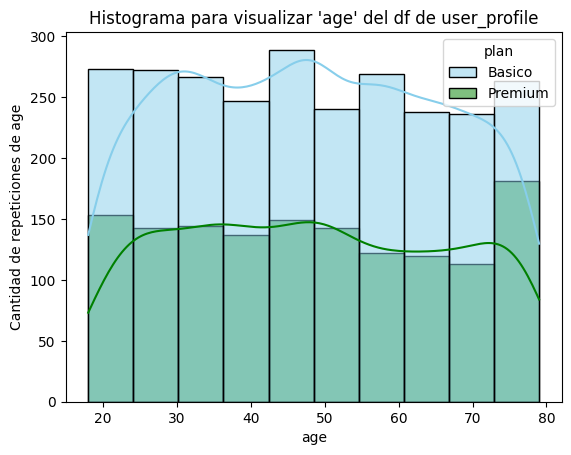

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT
1,10001,5,10,33.18,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaT
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT
...,...,...,...,...,...,...,...,...,...,...,...
3994,13995,6,3,21.24,Ana,Lopez,60.0,Medellín,2024-12-29 21:42:48.342085520,Basico,NaT
3995,13996,4,3,2.81,Carlos,Ramirez,24.0,Medellín,2024-12-30 04:17:06.256564144,Premium,NaT
3996,13997,5,3,11.34,Ana,Lopez,58.0,Bogotá,2024-12-30 10:51:24.171042768,Premium,NaT
3997,13998,6,6,22.95,Mariana,Lopez,57.0,Bogotá,2024-12-30 17:25:42.085521392,Basico,NaT


In [ ]:
# Histograma para visualizar la edad (age)
def crear_hist(df, columnas, nombre_df): #colocar nombre distintivo
    for col in columnas:
        sns.histplot(data=df, x=col, bins=10, hue='plan', palette=['skyblue', 'green'], kde=True) #
        plt.xlabel(f"{col}")
        plt.ylabel(f"Cantidad de repeticiones de {col}")
        plt.title(f"Histograma para visualizar '{col}' del df de {nombre_df}")
        plt.show()
    return df

crear_hist(user_profile, user_profile[['age']], "user_profile")

💡Insights:
- Distribución de las edadea parece ser simetrica, con un ligerisimo sesgo hacia la derecha (rightskewed)

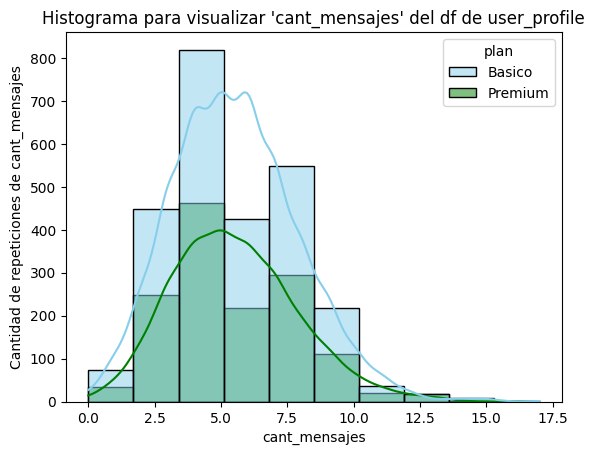

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT
1,10001,5,10,33.18,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaT
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT
...,...,...,...,...,...,...,...,...,...,...,...
3994,13995,6,3,21.24,Ana,Lopez,60.0,Medellín,2024-12-29 21:42:48.342085520,Basico,NaT
3995,13996,4,3,2.81,Carlos,Ramirez,24.0,Medellín,2024-12-30 04:17:06.256564144,Premium,NaT
3996,13997,5,3,11.34,Ana,Lopez,58.0,Bogotá,2024-12-30 10:51:24.171042768,Premium,NaT
3997,13998,6,6,22.95,Mariana,Lopez,57.0,Bogotá,2024-12-30 17:25:42.085521392,Basico,NaT


In [ ]:
# Histograma para visualizar la cant_mensajes
crear_hist(user_profile, user_profile[['cant_mensajes']], "user_profile") #  	cant_llamadas	cant_minutos_llamada

💡Insights:
- La grafíca parece tener un sesgo hacia la derecha (right skewed), muy poco usuarios que usan demasiado los SMS sensgan la media hacia la derecha

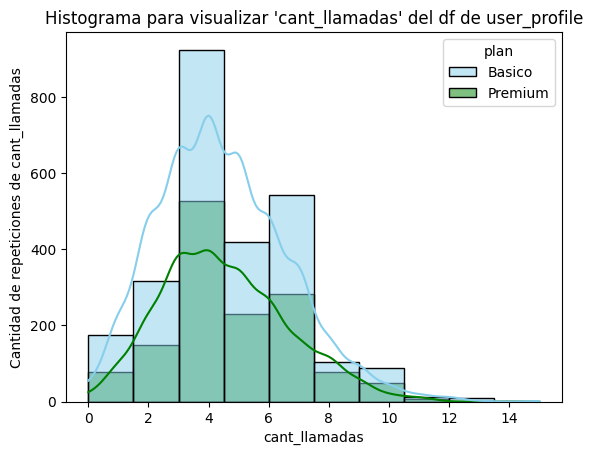

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT
1,10001,5,10,33.18,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaT
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT
...,...,...,...,...,...,...,...,...,...,...,...
3994,13995,6,3,21.24,Ana,Lopez,60.0,Medellín,2024-12-29 21:42:48.342085520,Basico,NaT
3995,13996,4,3,2.81,Carlos,Ramirez,24.0,Medellín,2024-12-30 04:17:06.256564144,Premium,NaT
3996,13997,5,3,11.34,Ana,Lopez,58.0,Bogotá,2024-12-30 10:51:24.171042768,Premium,NaT
3997,13998,6,6,22.95,Mariana,Lopez,57.0,Bogotá,2024-12-30 17:25:42.085521392,Basico,NaT


In [ ]:
# Histograma para visualizar la cant_llamadas
crear_hist(user_profile, user_profile[['cant_llamadas']], "user_profile")

💡Insights:
- La grafíca parece tener un sesgo hacia la derecha (right skewed), muy poco usuarios que usan demasiado llas llamadas diractas sensgan la media hacia la derecha

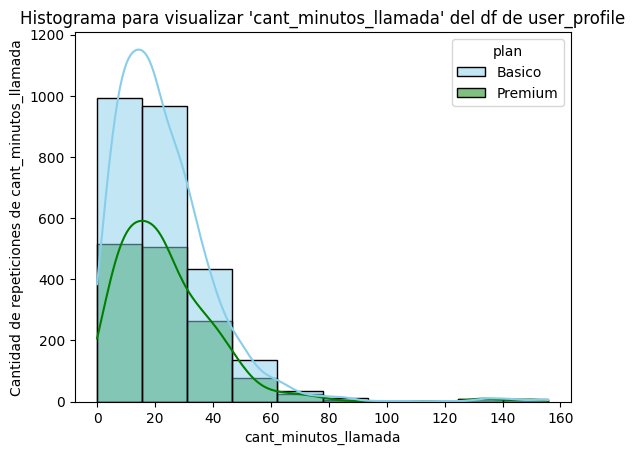

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT
1,10001,5,10,33.18,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaT
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT
...,...,...,...,...,...,...,...,...,...,...,...
3994,13995,6,3,21.24,Ana,Lopez,60.0,Medellín,2024-12-29 21:42:48.342085520,Basico,NaT
3995,13996,4,3,2.81,Carlos,Ramirez,24.0,Medellín,2024-12-30 04:17:06.256564144,Premium,NaT
3996,13997,5,3,11.34,Ana,Lopez,58.0,Bogotá,2024-12-30 10:51:24.171042768,Premium,NaT
3997,13998,6,6,22.95,Mariana,Lopez,57.0,Bogotá,2024-12-30 17:25:42.085521392,Basico,NaT


In [ ]:
# Histograma para visualizar la cant_minutos_llamada
crear_hist(user_profile, user_profile[['cant_minutos_llamada']], "user_profile")

💡Insights:
- Esta gráfica presenta el sesgo más grande pero al mismo tiempo el más revelador, lo usuarios no tienden a hacer muchas llamadas via red celular directa, pero cuando lo hacen tardan bastante en la llamada

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

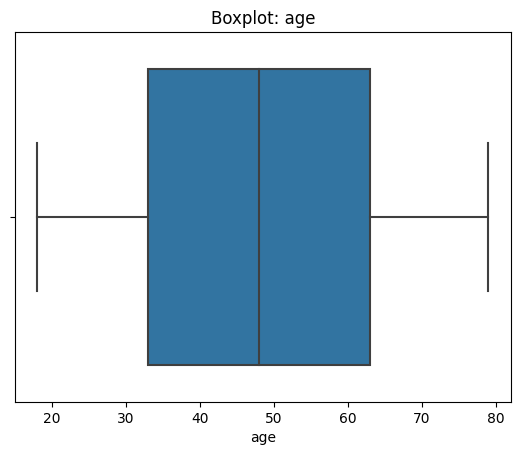

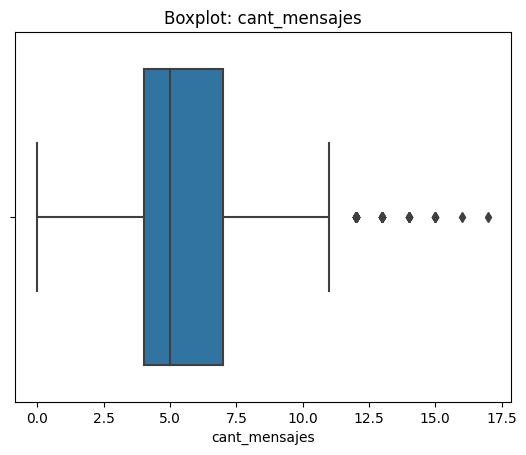

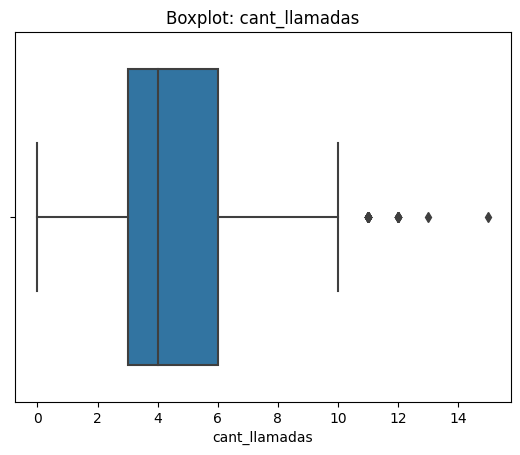

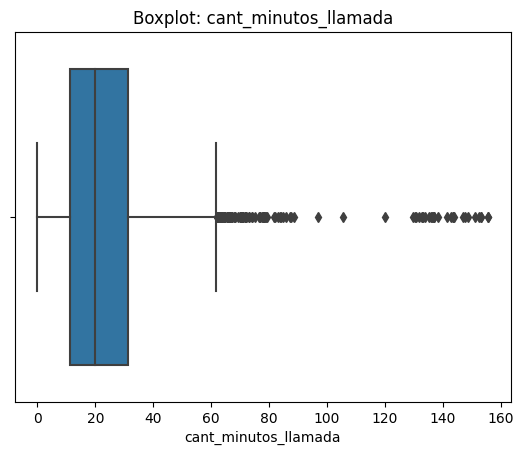

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT
1,10001,5,10,33.18,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaT
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT
...,...,...,...,...,...,...,...,...,...,...,...
3994,13995,6,3,21.24,Ana,Lopez,60.0,Medellín,2024-12-29 21:42:48.342085520,Basico,NaT
3995,13996,4,3,2.81,Carlos,Ramirez,24.0,Medellín,2024-12-30 04:17:06.256564144,Premium,NaT
3996,13997,5,3,11.34,Ana,Lopez,58.0,Bogotá,2024-12-30 10:51:24.171042768,Premium,NaT
3997,13998,6,6,22.95,Mariana,Lopez,57.0,Bogotá,2024-12-30 17:25:42.085521392,Basico,NaT


In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
def crear_boxplot(df, columnas):
    for col in columnas:
        sns.boxplot(data=df, x=col)
        plt.title(f"Boxplot: {col}")
        plt.show()
    return df

crear_boxplot(user_profile, columnas_numericas)

💡Insights:
- Age: No presenta outliers, y junto con su distribución parece ser bastante simetrica
- cant_mensajes: Presenta outliers hacia la derecha
- cant_llamadas: Presenta outliers hacia la derecha
- cant_minutos_llamada: Es el que más presenta outliers hacia la derecha

In [ ]:
# Calcular límites con el método IQR
columnas_limites = user_profile[["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]]

# Crea otro bucle para calcular los límites de esas columnas usando el método IQR y decide qué hacer con ellos

def metodo_IQR(df, columnas):
    for col in columnas:
        print(f"\n--- Columna: {col} ---")
        #calcular Q1
        Q1 = df[col].quantile(0.25)
        print('Primer cuartil: ', Q1)

        #calcular Q3
        Q3 = df[col].quantile(0.75)
        print('Tercer cuartil: ', Q3)
        #calcular IQR
        IQR = Q3 - Q1
        print('IQR: ', IQR)

        #calcular límite inferior
        lower = Q1 - 1.5 * IQR
        print('Límite inferior: ', lower)

        #calcular límite superior
        upper = Q3 + 1.5 * IQR
        print('Límite superior: ', upper)
    return df

metodo_IQR(user_profile, columnas_limites)




--- Columna: cant_mensajes ---
Primer cuartil:  4.0
Tercer cuartil:  7.0
IQR:  3.0
Límite inferior:  -0.5
Límite superior:  11.5

--- Columna: cant_llamadas ---
Primer cuartil:  3.0
Tercer cuartil:  6.0
IQR:  3.0
Límite inferior:  -1.5
Límite superior:  10.5

--- Columna: cant_minutos_llamada ---
Primer cuartil:  11.12
Tercer cuartil:  31.415
IQR:  20.295
Límite inferior:  -19.322500000000005
Límite superior:  61.8575


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT
1,10001,5,10,33.18,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaT
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT
...,...,...,...,...,...,...,...,...,...,...,...
3994,13995,6,3,21.24,Ana,Lopez,60.0,Medellín,2024-12-29 21:42:48.342085520,Basico,NaT
3995,13996,4,3,2.81,Carlos,Ramirez,24.0,Medellín,2024-12-30 04:17:06.256564144,Premium,NaT
3996,13997,5,3,11.34,Ana,Lopez,58.0,Bogotá,2024-12-30 10:51:24.171042768,Premium,NaT
3997,13998,6,6,22.95,Mariana,Lopez,57.0,Bogotá,2024-12-30 17:25:42.085521392,Basico,NaT


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
columnas_limites.describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: segun la lección KEEP es Cuando representan un comportamiento real como:

Clientes "whales" o de alto valor (order_value altos reales).
Productos premium con precios elevados.
Ventas grandes por fecha especial (Navidad, Black Friday).
Mantener datos es esencial para segmentación, cálculo de revenue e identificación de clientes valiosos.

- cant_mensajes: mantener outliers porque representan casos raros pero perfectamente posibles
- cant_llamadas: mantener outliers porque representan casos raros pero perfectamente posibles
- cant_minutos_llamada: mantener outliers porque representan casos raros pero perfectamente posibles

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
# Función para clasificar clientes
def classify_segment(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    # Manejo de valores nulos/faltantes
    if pd.isna(llamadas) or pd.isna(mensajes):
        return "Error en Datos"

    # Segmentación
    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile["grupo_uso"] = user_profile.apply(classify_segment, axis=1)
user_profile['grupo_uso'].value_counts()

Uso medio    2943
Bajo uso      778
Alto uso      278
Name: grupo_uso, dtype: int64

In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaT,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
# Función para clasificar clientes
def classify_segment(row):
    edad = row['age']

    # Manejo de valores nulos/faltantes
    if pd.isna(edad):
        return "Error en Datos"

    # Segmentación
    if edad < 30:
        return "Joven"
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile["grupo_edad"] = user_profile.apply(classify_segment, axis=1)
user_profile['grupo_edad'].value_counts()

Adulto          2017
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaT,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

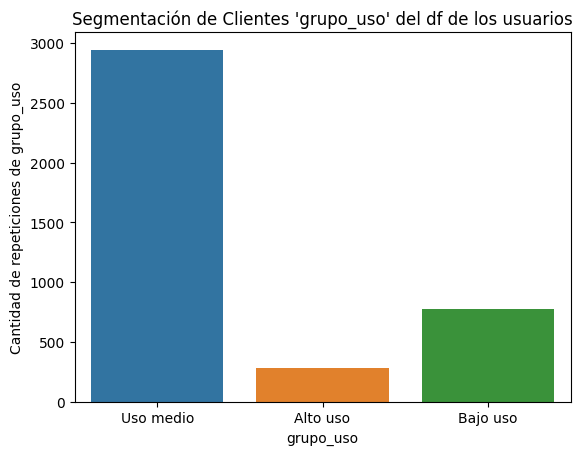

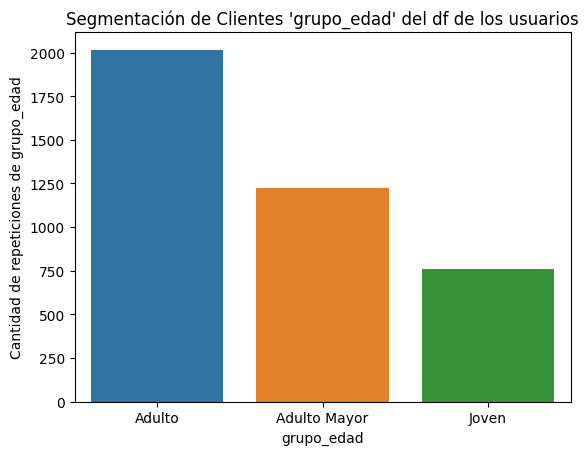

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaT,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,Bajo uso,Adulto Mayor
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3994,13995,6,3,21.24,Ana,Lopez,60.0,Medellín,2024-12-29 21:42:48.342085520,Basico,NaT,Uso medio,Adulto Mayor
3995,13996,4,3,2.81,Carlos,Ramirez,24.0,Medellín,2024-12-30 04:17:06.256564144,Premium,NaT,Bajo uso,Joven
3996,13997,5,3,11.34,Ana,Lopez,58.0,Bogotá,2024-12-30 10:51:24.171042768,Premium,NaT,Uso medio,Adulto
3997,13998,6,6,22.95,Mariana,Lopez,57.0,Bogotá,2024-12-30 17:25:42.085521392,Basico,NaT,Uso medio,Adulto


In [ ]:
# Visualización de los segmentos por uso
def count_plot(df, columnas, nombre_df):
    for col in columnas:
        sns.countplot(data=df, x=col)
        plt.xlabel(f"{col}")
        plt.ylabel(f"Cantidad de repeticiones de {col}")
        plt.title(f"Segmentación de Clientes '{col}' del df de {nombre_df}")
        plt.show()
    return df

count_plot(user_profile, user_profile[['grupo_uso', 'grupo_edad']], "los usuarios")


In [ ]:
# Visualización de los segmentos por edad
#YA


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- los datos contaban con columnas mal configuradas e incompletas, con datos de tipo MCAR y MAR lo que provocaba confusión y la imposibilidad de buenos analisis.
- Asi mismo se detectaron sentinels como ? en la columna "city" y -999 en la columna "age"
- Los formatos de fecha estaban configurados como object

🔍 **Segmentos por Edad**
- Se segmentó por edad y uso de los clientes mediante funciones y condiconales
- Los resultados arrojaron que el grupo de edad que predomina son los adultos, seguido de los adultos mayor y un grupo dejoven reducido
- como dato curioso descubierto con la IA los datos mas faltante de city (en df users):
False    32.514868
True     42.961620
Muestra que los datos faltantes tienden a depender de la edad de los mayores, es decir a mayor edad menos probabilidad de registrar la ciudad

📊 **Segmentos por Nivel de Uso**
- Los resultados arrojaron que el uso es predominantemente normal (tendencia al uso medio)
- El uso alto es más bien raro, incluso más que el uso bajo


➡️ Esto sugiere que las personas tienden hacia un consumo relativamente normal con clientes ballenas a los que se les podría ofrecer planes adaptados a altos niveles de consumo,


💡 **Recomendaciones**
- Focalizar las campañas de marketing hacia personas mayores de 30 años (adultos) para entender mejor el mainstream y las adaptaciones de marketing.
- Los planes de telefonía ilimitada podrías servir como buena publicidad para los clientes, puesto que estos igual no consumen tanto

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`